---
## 📡 GNSS-DEMO

Welcome to your hands-on guide for processing GNSS data with SAGE/GAGE! In this notebook, we’ll take you on a two-track journey:

1. #### **🚶 Traditional Serial Processing**  

   – Download RINEX files one by one to your local GeoLab environment  
   – Run the standard GNSS processing pipeline step-by-step  
   – See how long each stage takes and where the bottlenecks lie  

2. #### **☁️ Cloud-Optimized Workflow**  

   – Stream data directly from an AWS S3 bucket—no massive local downloads  
   – Parallelize your work with Dask-Gateway for lightning-fast throughput  
   – Compare performance metrics against the serial approach  

Don’t worry if “S3” and “Dask” are unfamiliar terms right now—we’ll introduce each concept with clear, jargon-free explanations right when you need them.

---

## 1️⃣ Traditional Serial Processing
In this section, we’ll explore the classic method of GNSS data handling which is downloading RINEX files to your GeoLab environment and processing them one by one.  
RINEX (Receiver Independent Exchange Format) is the open, ASCII-based standard for recording raw GNSS observations—packaging pseudorange, carrier-phase, navigation, and meteorological data into a human-readable, vendor-neutral text format.

More about 👉 [RINEX](https://igs.org/wg/rinex/)

**What you’ll do here:**  
1. **Set up storage:** Create a `./rinex_data` directory for your downloads.  
2. **Batch download:** Loop over days 1–9 of 2024 and fetch each RINEX file from the EarthScope archive on S3.  
3. **Parse with GeoRINEX:** Load the GPS L1C signal‐to‐noise ratio (`S1`) into an xarray dataset.  
4. **Compute daily mean SNR:** Calculate the average SNR for each file and record its date.  
5. **Clean up:** Delete each file after processing to keep your workspace tidy.  
6. **Time it all:** Use `time.time()` to capture the total download + processing runtime.  
7. **Visualize results:** Plot daily mean SNR vs. date, overlay the overall average, and annotate the total elapsed time in the title.  

First, we’ll install the GeoRINEX package into a temporary environment using a bash script. 

For more details, 👉 [GeoRINEX GitHub repository](https://github.com/geospace-code/georinex/tree/main) 👉 [Bash scripting inside notebook](https://stackoverflow.com/questions/58981651/how-to-run-a-shell-script-in-jupyter-notebook)

In [ ]:
!pip install georinex

Now, we need to build a function for authentication. This function kicks off a one-time, browser-based sign-in and then quietly refreshes your credentials so you don’t have to log in again. When you give it the web address of the data file and a folder on your computer, it securely fetches and saves the file for you. If the download fails—say the URL is wrong or your login has lapsed—it prints a straightforward error message so you know what to fix.

To learn more about how it works, 👉 [earthscope-sdk](https://pypi.org/project/earthscope-sdk/)

In [1]:
# ____ Authentication function __________________________________________________
import requests
from pathlib import Path
from earthscope_sdk.auth.device_code_flow import DeviceCodeFlowSimple
from earthscope_sdk.auth.auth_flow import NoTokensError

def get_es_file(url, directory_to_save_file='./', token_path='./'):
    """function to get earthscope data using es-sdk
    modified from https://gitlab.com/earthscope/public/earthscope-sdk

    Parameters
    ----------
    url : string
        url of desired file at gage-data.earthscope.org
    directory_to_save_file : str, optional
        path of directory in which to save the file, by default cwd
    token_path : str, optional
        path of directory in which to save the token, by default './'
    """
    # instantiate the device code flow subclass
    device_flow = DeviceCodeFlowSimple(Path(token_path))
    try:
      # get access token from local path
      device_flow.get_access_token_refresh_if_necessary()
    except NoTokensError:
      # if no token was found locally, do the device code flow
      device_flow.do_flow()
    token = device_flow.access_token

    # request a file and provide the token in the Authorization header
    file_name = Path(url).name

    r = requests.get(url, headers={"authorization": f"Bearer {token}"})
    if r.status_code == requests.codes.ok:
      # save the file
      with open(Path(Path(directory_to_save_file) / file_name), 'wb') as f:
          for data in r:
              f.write(data)
    else:
      #problem occured
      print(f"failure: {r.status_code}, {r.reason}")

/Users/ece/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


We first import the necessary packages for collecting, analyzing, plotting, and saving data, then set up the output directory and initialize lists to store our results.

In [2]:
# ── Imports & Setup ─────────────────────────────────────────────────────────────

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import georinex as gr                    # GeoRINEX: convert RINEX -> xarray datasets
from datetime import datetime, timedelta

# ── Configuration ──────────────────────────────────────────────────────────────

# Directory to store downloaded RINEX files
rinex_dir = "./rinex_data"
os.makedirs(rinex_dir, exist_ok=True)

# Lists to collect timing & SNR results
snr_list   = []    # daily mean signal-to-noise ratios
dates      = []    # corresponding dates
start_time = None  # will hold the timestamp when downloading starts

year = 2024        # the year of observation data

The following cell measures and reports how long it takes to download and process GNSS RINEX files for days 1–9 of the year. It:

* Records the start time.
* Loops over each day, building the file URL, downloading it with get_es_file, loading only the GPS L1 SNR data via GeoRINEX, computing the daily average SNR, recording that value and its calendar date, and then deleting the file to save space.
* After the loop finishes, records the end time and computes the total elapsed processing time.

In [3]:
# ── Serial Download & Processing Loop ──────────────────────────────────────────

# Record the start time
start_time = time.time()

# Loop over day-of-year (DOY) 1 through 9
for doy in np.arange(1, 10):
    # 1️⃣ Build the URL for the RINEX file on the EarthScope S3 archive
    filename = f"p057{doy:03d}0.24d.Z"
    url      = f"https://gage-data.earthscope.org/archive/gnss/rinex/obs/{year}/{doy:03d}/{filename}"
    print(f"Downloading: {url}")

    # 2️⃣ Download the file into our rinex_dir
    get_es_file(url, rinex_dir)

    # 3️⃣ Load the downloaded RINEX file into an xarray dataset
    filepath = os.path.join(rinex_dir, filename)
    obs      = gr.load(filepath, use='G', meas=['S1'])  
    #    - use='G' restricts to GPS satellites
    #    - meas=['S1'] loads only the L1C signal-to-noise ratio

    # 4️⃣ Compute the daily average SNR across all epochs & satellites
    daily_mean_snr = obs['S1'].mean().values
    snr_list.append(daily_mean_snr)

    # 5️⃣ Record the corresponding calendar date
    date = datetime(year, 1, 1) + timedelta(days=int(doy - 1))
    dates.append(date)

    # 6️⃣ Clean up: delete the RINEX file to save disk space
    os.remove(filepath)

# Record end time and compute total elapsed time
end_time  = time.time()
total_time = end_time - start_time

Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/001/p0570010.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/002/p0570020.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/003/p0570030.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/004/p0570040.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/005/p0570050.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/006/p0570060.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/007/p0570070.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/008/p0570080.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/009/p0570090.24d.Z


This cell computes and prints the overall mean SNR and total runtime, then plots your daily SNR values over time with a dashed line marking the mean, adds labels and a legend, and displays the figure.

Processed 9 days in 26.6 seconds.
Overall mean L1C SNR: 43.23


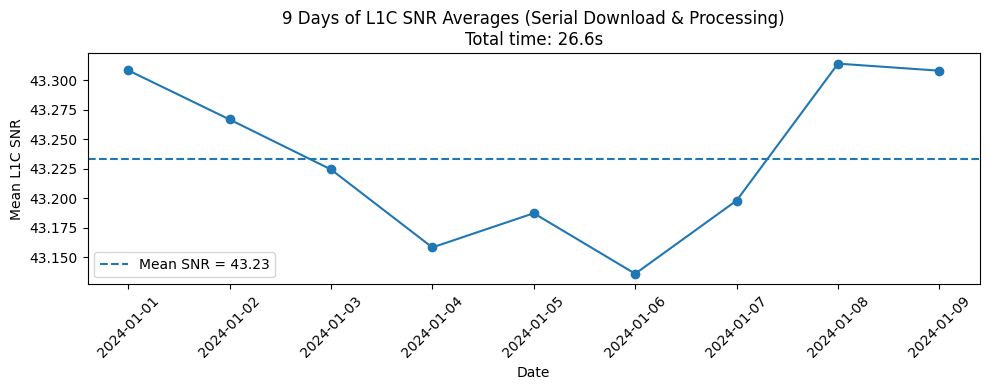

In [4]:
# ── Summary Statistics ─────────────────────────────────────────────────────────

overall_mean_snr = np.mean(snr_list)
print(f"Processed {len(snr_list)} days in {total_time:.1f} seconds.")
print(f"Overall mean L1C SNR: {overall_mean_snr:.2f}")

# ── Visualization ──────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 4))
plt.plot(dates, snr_list, marker='o', linestyle='-')
plt.axhline(overall_mean_snr, linestyle='--', label=f"Mean SNR = {overall_mean_snr:.2f}")
plt.title(f"{len(dates)} Days of L1C SNR Averages (Serial Download & Processing)\nTotal time: {total_time:.1f}s")
plt.xlabel("Date")
plt.ylabel("Mean L1C SNR")
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## 2️⃣ Cloud Optimized Workflow


First, lets tell the AWS CLI to start a Single Sign-On login flow using the “es-dev” profile—opening your browser to authenticate and caching temporary credentials for that profile.

In [ ]:
!aws sso login --profile es-dev

Now, lets run following snippet that signs you into AWS under the “es-dev” profile and fetches your access key, secret key, and session token. It then freezes those credentials into an unchangeable snapshot so they won’t refresh or expire mid-task. Finally, it bundles the S3 region, a parallel I/O setting, and your locked-in credentials into a configuration dictionary for seamless, secure access.

We will use **Boto3**, that spins up an AWS session using your “es-dev” profile and pulls out the access keys and token to configure secure S3 access.

To learn more  👉  [Boto3](https://boto3.amazonaws.com/v1/documentation/api/latest/index.html)

In [ ]:
import boto3
session=boto3.Session(profile_name='es-dev')
credentials=session.get_credentials()
credentials=credentials.get_frozen_credentials()

tdb_config={"vfs.s3.region": "us-east-2", "sm.io_concurrency_level": 12, 
                                              "vfs.s3.aws_access_key_id":credentials.access_key, "vfs.s3.aws_secret_access_key":credentials.secret_key,
                                             "vfs.s3.aws_session_token":credentials.token}

Once you have figured out cloud login, let's sets up a GNSS data request by defining a station code (P057), endpoint ID, year (2024), a start date (“2024-05-11”) and a 12-hour window, converts the numeric observation code (12611) into text form, builds the S3 path to the station’s “.tdb” file, computes the end date by adding the duration to the start, and finally prints out the full file URI along with the start and end timestamps.

In [ ]:
from datetime import datetime, timedelta

# 1. Define the station/project identifier
pnum = 'P057'  
#    This string tags which GNSS station we’re working with (e.g., P057 → P057.tdb later).

# 2. Store an endpoint ID or tracking token (if needed for logging/auth)
edid = "01GVDXYKWXCFP2N5WAJN4CX36F"  

# 3. Set the observation year
year = 2024  
#    We use this to construct date ranges or URLs tied to a specific year.

# 4. Specify the start time as an ISO-formatted string
start_time = '2024-05-11'  
#    This marks the beginning of our data window.

# 5. Define how long (in hours) we want data from that start
duration = '12'  
#    Here, '12' means a 12-hour span.

# 6. Choose the satellite constellation code
constell = 0  
#    Conventionally, 0 = GPS (other constellations get other codes).

# 7. Set the numeric observation code (e.g., L1C → 12611)
obs_code = 12611  

# 8. Convert the numeric code into a 2-byte big-endian string
#    - int(obs_code)            ensures it’s an integer
#    - .to_bytes(2, 'big')      packs it into 2 bytes, big-endian order
#    - .decode('utf-8')         turns those bytes into a text string
obs_code_str = int(obs_code).to_bytes(2, 'big').decode("utf-8")  

# 9. Define the base S3 bucket URI where .tdb files are stored
bucket = 's3://repository-stage-us-east-2-mlmoghi3ooss/geolab-gnss-demo/'

# 10. Build the full URI to our station’s .tdb file
uri = bucket + pnum + ".tdb"  
#     e.g., 's3://…/geolab-gnss-demo/P057.tdb'

# 11. Parse the start_time string into a datetime object
start_date = datetime.fromisoformat(start_time)  

# 12. Create a timedelta representing our duration in hours
durationz = timedelta(hours=int(duration))  

# 13. Compute the end date by adding the duration to the start
end_date = start_date + durationz  

# 14. Print everything for verification
print(f"URI:        {uri}")
print(f"Start Date: {start_date}")
print(f"End Date:   {end_date}")

The following cell times how long it takes to open (and upgrade, if needed) a remote TileDB array on S3, load the specified time‐range slice into a pandas DataFrame, and then tag each row with the GPS constellation and observation code.

In [ ]:
%%time
# With pandas
with tiledb.open(uri, mode="r", config=tdb_config,) as A:
    A.upgrade_version()
    # note that array indexes are half-open like NumPy
    # df = A.df[unix_time_millis(start_date): unix_time_millis(end_date),constell,:,obs_code]
    df = A.df[unix_time_millis(start_date): unix_time_millis(end_date),:] 

df["constell"] = constell
df["obs_code"] = obs_code

The following cell measures how long it takes to loop over the first 50 days, reading each day’s SNR slice from the remote TileDB array on S3 to compute and collect daily mean values. After timing the process, it plots the daily means with a horizontal line marking the overall average and a title noting the number of days and total runtime.

In [ ]:
%%time
start_t = time.time()

snr_li=[]
date_li=[]
for doy in np.arange(1,51):
    start=datetime(year, 1, 1) + timedelta(days=int(doy - 1))
    date_li+=[start]
    end=start+timedelta(days=1)
    start=unix_time_millis(start)
    end=unix_time_millis(end)
  
    with tiledb.open(uri,mode="r", config=tdb_config,) as A:
        df=A.df[slice(int(start), int(end)),:]['snr']
        snr_li+=[df.mean()]
        
for_loop=np.nanmean(np.array(snr_li))

end_t = time.time()
for_loop_t=end_t - start_t

# Plot results
plt.plot(date_li, snr_li)
plt.axhline(for_loop)
plt.xticks(rotation=45)
plt.title('%s Days of L1C SNR Average \n by reading from S3 in daily chunks took %.1f seconds' %(len(date_li),for_loop_t))
plt.show()